# Chapter 3: Lie Groups

**Source Span.** `Foundations of Differentiable Manifolds and Lie Groups.pdf` printed pages `82-137`, covering Lie groups and Lie algebras, homomorphisms, Lie subgroups, coverings, simply connected Lie groups, the exponential map, continuous homomorphisms, closed subgroups, the adjoint representation, automorphisms and derivations, homogeneous manifolds, and exercises.

**Chapter Goal.** See how group multiplication, smooth structure, and infinitesimal tangent algebra determine each other. Matrix groups provide the computational laboratory: the tangent space at the identity becomes a Lie algebra, exponentials turn algebra elements into one-parameter subgroups, brackets measure noncommutativity, adjoint actions transport infinitesimal data, and quotients by closed subgroups produce homogeneous manifolds.

The notebook uses original matrix examples and low-dimensional visualizations. It does not copy source text or figures. The checks record exactly the invariants the chapter uses: determinant and orthogonality constraints, commutator closure, exponential residuals, covering periodicity, adjoint trace preservation, and orbit/stabilizer data.


In [1]:
from pathlib import Path
import json, math, sys
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import sympy as sp
import plotly.graph_objects as go
BOOK_ROOT=None
for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate/'AGENTS.md').exists() and (candidate/'source_map.json').exists(): BOOK_ROOT=candidate; break
if BOOK_ROOT is None: raise RuntimeError('book root not found')
if str(BOOK_ROOT) not in sys.path: sys.path.insert(0,str(BOOK_ROOT))
from utils.artifacts import assert_artifacts, chapter_artifact_root, display_artifact, save_csv, save_json, save_matplotlib, save_plotly_html
UNIT_KEY='chapter-03-lie-groups'
ARTIFACT_ROOT=chapter_artifact_root(UNIT_KEY, BOOK_ROOT)
FIGURES,HTML,CHECKS,TABLES=(ARTIFACT_ROOT/name for name in ['figures','html','checks','tables'])
TRACKED_ARTIFACTS=[]
np.set_printoptions(precision=5,suppress=True)
print(f'Book root: {BOOK_ROOT}')


Book root: D:\Geometry\Foundations-of-Differentiable-Manifolds-and-Lie-Groups


## Visual Storyboard

1. **Matrix group constraints.** `SO(2)` is drawn as rotations acting on a vector, with determinant and orthogonality residuals checked.
2. **Lie algebra and exponential map.** The skew-symmetric generator `J` exponentiates to rotations; the derivative at the identity recovers `J`.
3. **Lie bracket closure.** A small `sl(2)` basis shows how commutators remain in the Lie algebra and encode noncommutativity.
4. **Covering and adjoint labs.** The exponential covering `R -> S^1` and adjoint conjugation are visualized with periodicity and trace/determinant checks.
5. **Homogeneous manifold dependency graph.** Quotients, stabilizers, orbits, closed subgroups, and the adjoint representation are connected as the chapter's proof flow.

## Library Routing

| Concept | Representation | Library | Why it fits | Check |
| --- | --- | --- | --- | --- |
| Matrix Lie groups | Rotation action and constraints | Matplotlib + NumPy | Matrix groups make smooth group laws inspectable | `R.T R=I`, `det R=1` |
| Exponential map | One-parameter subgroup | Plotly + SymPy | Exponential is a parameterized curve in the group | derivative at zero and periodicity |
| Lie bracket | Commutator table | SymPy + CSV | Brackets are exact matrix algebra | closure in `sl(2)` |
| Adjoint/homogeneous | Conjugation and orbit-stabilizer | Matplotlib + NetworkX | Shows transport of algebra and quotient logic | trace preserved; orbit is circle |


## Matrix Groups And Exponentials

A Lie group is both a group and a manifold, with smooth multiplication and inverse. Matrix groups make this visible: constraints such as `R^T R = I` and `det R = 1` cut out submanifolds inside matrix space, and multiplication is ordinary matrix multiplication. The tangent space at the identity of `SO(2)` consists of skew-symmetric matrices. Exponentiating the generator `J` gives the full rotation subgroup.

The first lab plots rotations of a vector around the circle and records the group constraints. The second lab treats the exponential map as a covering of the circle by the real line, showing that angles separated by `2π` map to the same group element.


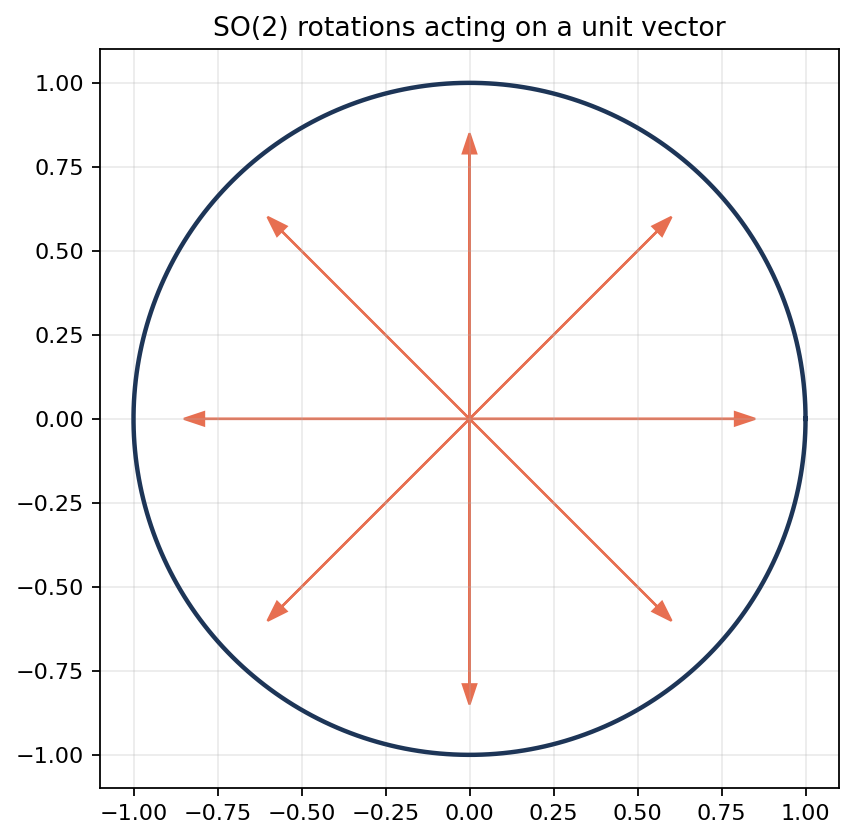

{'constraint_residual': 3.161250676874014e-16}

In [2]:
def R(theta):
    return np.array([[np.cos(theta), -np.sin(theta)],[np.sin(theta), np.cos(theta)]])
J=np.array([[0.,-1.],[1.,0.]])
theta=np.linspace(0,2*np.pi,300)
vecs=np.array([R(t)@np.array([1.,0.]) for t in theta])
residuals=[]
for t in np.linspace(-2*np.pi,2*np.pi,25):
    Rt=R(t); residuals.append(np.linalg.norm(Rt.T@Rt-np.eye(2))+abs(np.linalg.det(Rt)-1))
constraint_residual=float(max(residuals))
fig, ax=plt.subplots(figsize=(6,6))
ax.plot(vecs[:,0],vecs[:,1],color='#1d3557',lw=2)
for t in np.linspace(0,2*np.pi,8,endpoint=False):
    v=R(t)@np.array([1.,0.]); ax.arrow(0,0,.85*v[0],.85*v[1],head_width=.04,color='#e76f51',length_includes_head=True)
ax.set_aspect('equal',adjustable='box'); ax.grid(alpha=.25); ax.set_title('SO(2) rotations acting on a unit vector')
rot_path=save_matplotlib(fig, FIGURES/'matrix-group-so2-constraints.png'); plt.close(fig)
rot_json=save_json({'max_orthogonal_det_residual':constraint_residual,'generator_J':J.tolist()}, CHECKS/'matrix-group-so2-constraints.json')
TRACKED_ARTIFACTS.extend([rot_path,rot_json]); display_artifact(rot_path,width=640)
{'constraint_residual':constraint_residual}


In [3]:
t=sp.symbols('t')
Jsp=sp.Matrix([[0,-1],[1,0]])
expJ=sp.exp(t*Jsp)
derivative_at_zero=sp.diff(expJ,t).subs(t,0)
exp_check=sp.simplify(derivative_at_zero-Jsp)==sp.zeros(2)
angles=np.linspace(-4*np.pi,4*np.pi,1000)
fig=go.Figure()
fig.add_trace(go.Scatter(x=angles,y=np.cos(angles),mode='lines',name='cos t'))
fig.add_trace(go.Scatter(x=angles,y=np.sin(angles),mode='lines',name='sin t'))
fig.add_vline(x=0,line_color='#444'); fig.add_vline(x=2*np.pi,line_color='#888',line_dash='dash')
fig.update_layout(title='Exponential covering R -> SO(2): t and t+2pi give the same rotation',xaxis_title='t',yaxis_title='matrix entries',width=800,height=520)
exp_html=save_plotly_html(fig, HTML/'exponential-map-so2-covering.html')
period_residual=float(np.linalg.norm(R(0)-R(2*np.pi)))
exp_json=save_json({'derivative_at_zero_matches_generator':bool(exp_check),'period_residual_R0_R2pi':period_residual}, CHECKS/'exponential-map-so2-covering.json')
TRACKED_ARTIFACTS.extend([exp_html,exp_json]); display_artifact(exp_html,width=840,height=520)
{'exp_check':exp_check,'period_residual':period_residual}


D:\Geometry\.venv\Lib\site-packages\IPython\core\display.py:447: UserWarning: Consider using IPython.display.IFrame instead
  warnings.warn("Consider using IPython.display.IFrame instead")


{'exp_check': True, 'period_residual': 3.463824224941973e-16}

## Lie Brackets, Adjoint Action, And Homogeneous Spaces

The Lie algebra bracket of a matrix group is the commutator `AB-BA`. It measures the first-order failure of flows to commute. In `sl(2)`, the trace-zero matrices are closed under this bracket. The adjoint representation transports Lie algebra elements by conjugation, `Ad_g(X)=gXg^{-1}`, preserving structural invariants such as trace.

Homogeneous spaces appear when a Lie group acts transitively on a manifold. The circle is a simple model: `SO(2)` acts transitively on `S^1`, and the orbit of a point is the whole circle. More generally Warner's quotient construction `G/H` depends on closed subgroups and stabilizers.


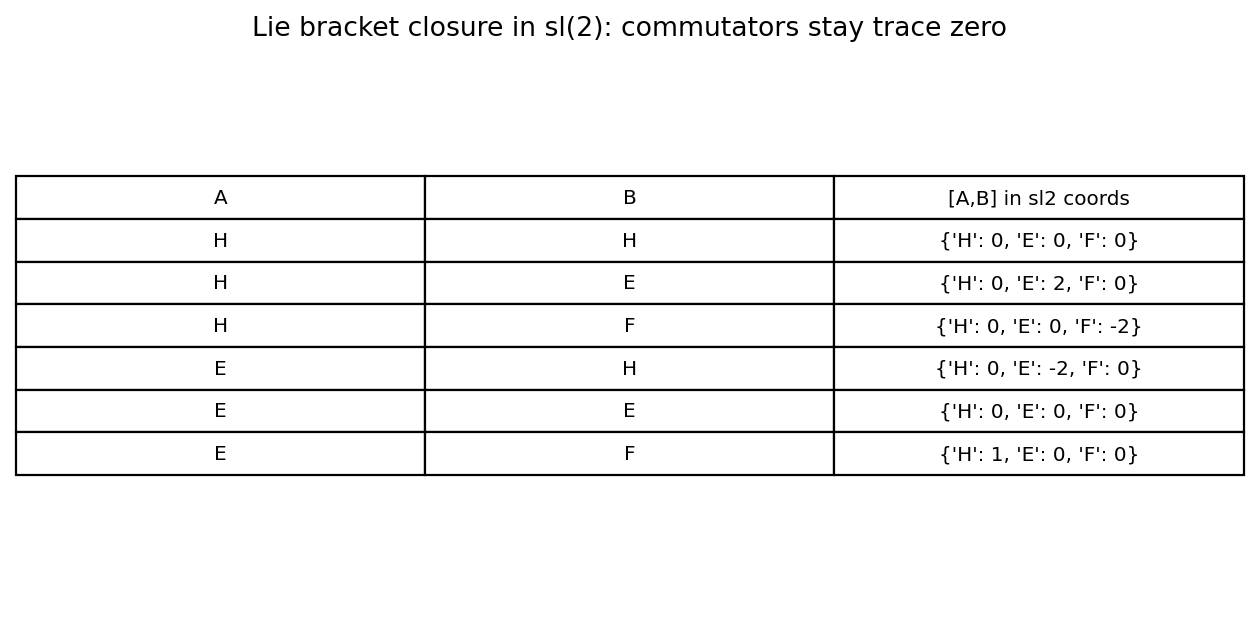

[{'left': 'H',
  'right': 'H',
  'trace': '0',
  'commutator_coords': "{'H': 0, 'E': 0, 'F': 0}"},
 {'left': 'H',
  'right': 'E',
  'trace': '0',
  'commutator_coords': "{'H': 0, 'E': 2, 'F': 0}"},
 {'left': 'H',
  'right': 'F',
  'trace': '0',
  'commutator_coords': "{'H': 0, 'E': 0, 'F': -2}"},
 {'left': 'E',
  'right': 'H',
  'trace': '0',
  'commutator_coords': "{'H': 0, 'E': -2, 'F': 0}"}]

In [4]:
H=sp.Matrix([[1,0],[0,-1]]); E=sp.Matrix([[0,1],[0,0]]); F=sp.Matrix([[0,0],[1,0]])
basis={'H':H,'E':E,'F':F}
def coords_sl2(M):
    return {'H':sp.simplify(M[0,0]), 'E':sp.simplify(M[0,1]), 'F':sp.simplify(M[1,0])}
rows=[]
for a,A in basis.items():
    for b,B in basis.items():
        C=A*B-B*A
        rows.append({'left':a,'right':b,'trace':str(sp.trace(C)),'commutator_coords':str(coords_sl2(C))})
bracket_csv=save_csv(rows, TABLES/'sl2-lie-bracket-table.csv')
bracket_json=save_json({'rows':rows,'all_traces_zero':all(row['trace']=='0' for row in rows)}, CHECKS/'sl2-lie-bracket-table.json')
TRACKED_ARTIFACTS.extend([bracket_csv,bracket_json])

fig, ax=plt.subplots(figsize=(9,4.5)); ax.axis('off')
show=rows[:6]
table=ax.table(cellText=[[r['left'],r['right'],r['commutator_coords']] for r in show],colLabels=['A','B','[A,B] in sl2 coords'],cellLoc='center',loc='center')
table.auto_set_font_size(False); table.set_fontsize(9); table.scale(1.1,1.6)
ax.set_title('Lie bracket closure in sl(2): commutators stay trace zero')
bracket_path=save_matplotlib(fig, FIGURES/'sl2-lie-bracket-closure.png'); plt.close(fig)
TRACKED_ARTIFACTS.append(bracket_path); display_artifact(bracket_path,width=760)
rows[:4]


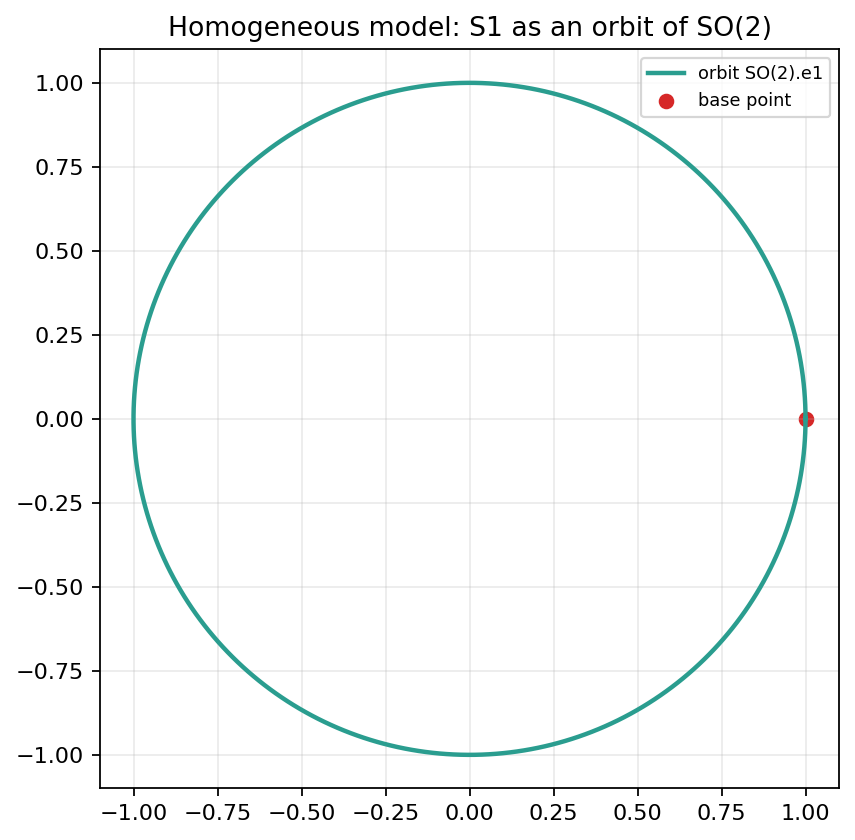

{'trace_before': '0', 'trace_after': '0', 'det_before': '0', 'det_after': '0'}

In [5]:
g=sp.Matrix([[2,1],[1,1]])
X=sp.Matrix([[0,1],[0,0]])
AdX=sp.simplify(g*X*g.inv())
ad_check={'trace_before':str(sp.trace(X)),'trace_after':str(sp.trace(AdX)),'det_before':str(X.det()),'det_after':str(sp.simplify(AdX.det()))}
# orbit of SO(2) acting on e1
orbit=np.array([R(t)@np.array([1.,0.]) for t in np.linspace(0,2*np.pi,300)])
fig, ax=plt.subplots(figsize=(6,6))
ax.plot(orbit[:,0],orbit[:,1],color='#2a9d8f',lw=2,label='orbit SO(2).e1')
ax.scatter([1],[0],color='#d62828',label='base point')
ax.set_aspect('equal',adjustable='box'); ax.grid(alpha=.25); ax.legend(fontsize=8); ax.set_title('Homogeneous model: S1 as an orbit of SO(2)')
ad_path=save_matplotlib(fig, FIGURES/'adjoint-and-homogeneous-orbit.png'); plt.close(fig)
ad_json=save_json({'adjoint_matrix':[[str(v) for v in row] for row in AdX.tolist()], **ad_check, 'orbit_radius_residual':float(max(abs(np.linalg.norm(p)-1) for p in orbit))}, CHECKS/'adjoint-and-homogeneous-orbit.json')
TRACKED_ARTIFACTS.extend([ad_path,ad_json]); display_artifact(ad_path,width=640)
ad_check


## Source Coverage Notes

Warner's Lie group chapter is broader than the matrix examples shown here, but the examples are chosen to expose the recurring logic. Matrix groups make the identity tangent space explicit, and that tangent space is the Lie algebra. Homomorphisms differentiate to Lie algebra homomorphisms; under simply connected hypotheses the infinitesimal map can be integrated back to a group homomorphism. Covering spaces enter because global topology can prevent an otherwise valid local algebra map from descending to the desired group.

The closed subgroup and homogeneous manifold material is also represented in miniature. A closed subgroup has a compatible Lie subgroup structure, and a quotient `G/H` becomes a manifold when the subgroup is closed. The orbit picture of the circle is a simple case of this quotient logic: a group action, a stabilizer, and a homogeneous space. The adjoint lab records how the group acts on its own Lie algebra by conjugation, setting up automorphisms, derivations, and structure constants.


## Applied Lab: Reading A Lie Group From Its Infinitesimal Data

Warner's chapter repeatedly moves between global groups and infinitesimal algebras. For matrix groups, compute the constraint defining the group, differentiate it at the identity to get the Lie algebra, exponentiate algebra elements to one-parameter subgroups, and use commutators to measure noncommutativity. Homomorphisms differentiate to Lie algebra homomorphisms, and for simply connected groups the infinitesimal data controls the global map. Closed subgroups and stabilizers then produce homogeneous manifolds.


## Learner Inspection Targets

When reading the visuals, keep the global-local distinction explicit. The circle covered by the exponential map is a global object with periodicity; the Lie algebra generator is local tangent data at the identity. The bracket table belongs to the infinitesimal side, while the orbit and quotient picture belongs to the global side. Warner's main theme is that these sides determine one another under precise hypotheses, especially connectedness, simple connectivity, and closedness of subgroups.


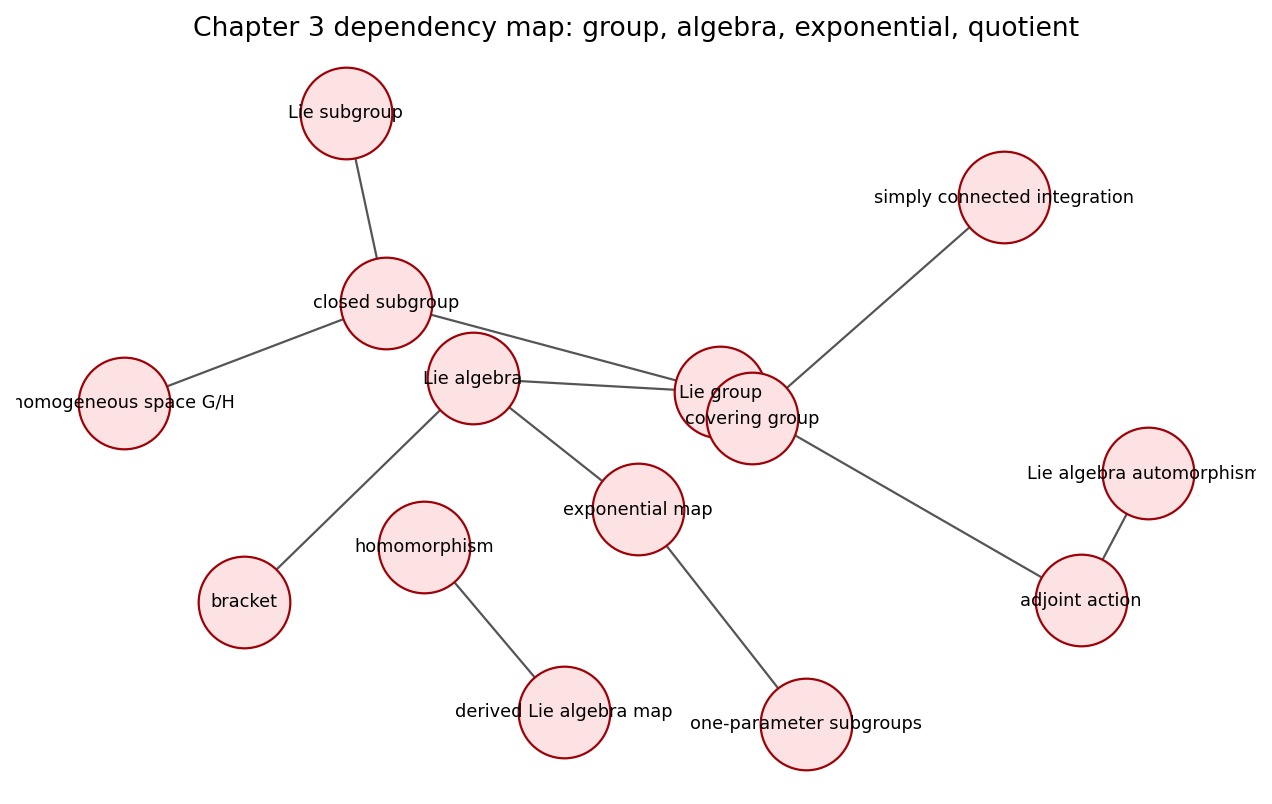

{'nodes': 14, 'edges': 11}

In [6]:
G=nx.DiGraph(); edges=[('Lie group','Lie algebra'),('Lie group','closed subgroup'),('Lie algebra','bracket'),('Lie algebra','exponential map'),('exponential map','one-parameter subgroups'),('homomorphism','derived Lie algebra map'),('covering group','simply connected integration'),('closed subgroup','Lie subgroup'),('closed subgroup','homogeneous space G/H'),('adjoint action','Lie algebra automorphisms'),('Lie group','adjoint action')]
G.add_edges_from(edges); pos=nx.spring_layout(G,seed=303,k=.85)
fig,ax=plt.subplots(figsize=(10,6)); nx.draw_networkx_edges(G,pos,ax=ax,arrows=True,arrowstyle='-|>',edge_color='#555'); nx.draw_networkx_nodes(G,pos,ax=ax,node_color='#fde2e4',edgecolors='#9d0208',node_size=1700); nx.draw_networkx_labels(G,pos,ax=ax,font_size=8); ax.axis('off'); ax.set_title('Chapter 3 dependency map: group, algebra, exponential, quotient')
dep_path=save_matplotlib(fig, FIGURES/'lie-groups-exponential-quotient-dependency-map.png'); plt.close(fig)
dep_json=save_json({'nodes':list(G.nodes),'edges':edges,'acyclic':nx.is_directed_acyclic_graph(G)}, CHECKS/'lie-groups-exponential-quotient-dependency-map.json')
TRACKED_ARTIFACTS.extend([dep_path,dep_json]); display_artifact(dep_path,width=780)
{'nodes':G.number_of_nodes(),'edges':G.number_of_edges()}


In [7]:
assert constraint_residual < 1e-12
assert exp_check and period_residual < 1e-12
assert all(row['trace']=='0' for row in rows)
assert ad_check['trace_before'] == ad_check['trace_after'] == '0'
assert nx.has_path(G,'Lie group','homogeneous space G/H')
assert_artifacts(TRACKED_ARTIFACTS,min_bytes=80)
final_sanity={'unit':UNIT_KEY,'tracked_artifacts':len(TRACKED_ARTIFACTS),'core_checks':['SO(2) constraints','exponential covering','sl2 bracket closure','adjoint invariants','homogeneous quotient DAG']}
final_sanity


{'unit': 'chapter-03-lie-groups',
 'tracked_artifacts': 11,
 'core_checks': ['SO(2) constraints',
  'exponential covering',
  'sl2 bracket closure',
  'adjoint invariants',
  'homogeneous quotient DAG']}

## Takeaways

A Lie group is a smooth group whose tangent space at the identity carries a Lie algebra. The exponential map turns algebra elements into one-parameter subgroups, brackets capture infinitesimal noncommutativity, and homomorphisms are constrained by their derivatives. Closed subgroups are Lie subgroups, and homogeneous manifolds arise as quotient spaces `G/H`. The chapter's global theorems are best read alongside these local checks.
